# Supervised Autoencoder for ETF Rotation

**Purpose.** Evaluate the supervised autoencoder (SAE) as a direct predictor of 21-day ETF
returns through purged walk-forward validation.

**Learning objectives**

- distinguish the SAE's direct prediction role from latent factor-premium forecasting;
- trace the complete modeling-input identity through the shared cache-or-train runner;
- apply a reporting checkpoint fixed before validation results are inspected; and
- compute rank IC within each validation date before applying HAC inference across time.

**Book reference.** Chapter 14, Section 14.7, "The stochastic discount factor and the
supervised autoencoder models."

**Prerequisites.** The ETF financial and model-based features, 21-day labels, fold-scoped
temporal features, and purged walk-forward splits produced by the case-study pipeline.

In [1]:
"""Evaluate the ETF supervised autoencoder through the shared model runner."""

import warnings

# Load PyTorch's bundled CUDA runtime before other ML4T libraries.
import torch

# isort: split
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython import get_ipython
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series

from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from case_studies.utils.latent_factors.library_bridge import preferred_latent_device
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, zero_line

warnings.filterwarnings("ignore")
shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = False
MODEL_NAME = "sae"
SEED = 42

In [3]:
REPORTING_CHECKPOINT = 50
HORIZON = 21
set_global_seeds(SEED)

PREFERRED_DEVICE = preferred_latent_device()
assert ("cuda" if torch.cuda.is_available() else "cpu") == PREFERRED_DEVICE
print(f"Preferred SAE device: {PREFERRED_DEVICE}")

Preferred SAE device: cuda


## Establish the evaluation contract

The SAE fits its encoder and prediction heads separately within each training fold. Fold-scoped
temporal state replaces the corresponding columns before each fit, and the label horizon is
separated from validation by the configured purge and embargo. All reported predictions must
precede the sealed holdout.

The input digest below covers the financial, model-based, label, and setup artifacts. The ETF
universe was selected retrospectively, so this remains a development-validation estimate with
survivorship risk. Three financial inputs also use finalized FRED yield-curve history rather than
strict first-release vintages. Disabling the SAE's optional direct macro panel does not remove
those financial features.

In [4]:
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
assert MODEL_NAME in configured_models(context)
assert context.input_data_spec["version"] == "v1"
assert context.macro_context_spec is not None
assert context.macro_context_spec["policy"] == "disabled"
assert context.temporal_by_fold is not None
assert context.temporal_feature_names
assert context.device == PREFERRED_DEVICE

pl.DataFrame(
    {
        "label": [context.primary_label],
        "features": [len(context.feature_names)],
        "folds": [len(context.splits)],
        "input_version": [context.input_data_spec["version"]],
        "modeling_input_digest": [context.input_data_spec["input_digest"]],
        "preferred_device": [PREFERRED_DEVICE],
    }
)

label,features,folds,input_version,modeling_input_digest,preferred_device
str,i64,i64,str,str,str
"""fwd_ret_21d""",71,8,"""v1""","""sha256:8384ded464c95f36b9baff0…","""cuda"""


## Run walk-forward validation

Epoch 50 is the predeclared reporting endpoint. The shared runner loads the newest exact
specification match when one exists. On a cache miss it fits and registers the same specification,
preferring CUDA when available and falling back to CPU otherwise. Validation performance cannot
choose the reported checkpoint.

In [5]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="11e_supervised_autoencoder",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
    reporting_epoch=REPORTING_CHECKPOINT,
)

model_result = result["model_results"][0]
assert model_result["best_epoch"] == REPORTING_CHECKPOINT
assert result["fold_metrics"][MODEL_NAME]["fold_id"].n_unique() == len(context.splits)

execution_mode = (
    "registry cache" if model_result["elapsed_s"] == 0.0 else f"new {PREFERRED_DEVICE} fit"
)
pl.DataFrame(result["model_results"]).with_columns(pl.lit(execution_mode).alias("execution_mode"))

Latent factor CV: 1 models × 8 folds
Log file: <ML4T_OUTPUT_DIR>/etfs/run_log/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=50
  sae: loaded registry (best IC=+0.0654)
  Best: sae (IC=+0.0654)


model_name,mean_ic,best_epoch,n_folds,elapsed_s,started_at,execution_mode
str,f64,i64,i64,f64,null,str
"""sae""",0.0654,50,8,0.0,null,"""registry cache"""


## Recompute daily IC at every checkpoint

One Spearman rank correlation is computed per decision date before averaging across time. This
gives every date equal weight even when the number of eligible ETFs changes. A 20-lag Newey-West
correction reflects overlap in the 21-day forward-return label.

In [6]:
all_predictions = result["all_predictions"][MODEL_NAME]
checkpoint_stats = []
daily_series_by_epoch = {}
uncertainty_by_epoch = {}

for epoch in sorted(all_predictions["epoch"].unique().to_list()):
    epoch_predictions = all_predictions.filter(pl.col("epoch") == epoch)
    epoch_daily_ic = cross_sectional_ic_series(
        epoch_predictions,
        epoch_predictions,
        pred_col="y_score",
        ret_col="y_true",
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=5,
    ).sort("timestamp")
    epoch_stats = compute_ic_uncertainty(epoch_daily_ic.select("ic"), horizon=HORIZON)
    daily_series_by_epoch[int(epoch)] = epoch_daily_ic
    uncertainty_by_epoch[int(epoch)] = epoch_stats
    checkpoint_stats.append({"epoch": int(epoch), **epoch_stats})

checkpoint_metrics = pl.DataFrame(checkpoint_stats).sort("epoch")
checkpoint_metrics.select(
    "epoch",
    "mean_ic",
    "se_hac",
    "ci_hac_lower",
    "ci_hac_upper",
    "t_hac",
    "p_hac",
    "n_days",
)

epoch,mean_ic,se_hac,ci_hac_lower,ci_hac_upper,t_hac,p_hac,n_days
i64,f64,f64,f64,f64,f64,f64,i64
5,-0.012024,0.019527,-0.050319,0.02627,-0.615797,0.538098,2016
10,0.00051,0.018515,-0.035801,0.036821,0.027558,0.978018,2016
15,0.001368,0.014682,-0.027426,0.030161,0.09314,0.925802,2016
20,0.013219,0.017094,-0.020304,0.046742,0.773337,0.439414,2016
25,0.008647,0.020197,-0.030961,0.048255,0.42814,0.668595,2016
30,0.021186,0.017893,-0.013905,0.056276,1.18402,0.236545,2016
35,0.052393,0.016695,0.019652,0.085135,3.138218,0.001724,2016
40,0.061028,0.018475,0.024796,0.09726,3.303258,0.000972,2016
45,0.065514,0.0196,0.027076,0.103952,3.342598,0.000845,2016


## Verify the fixed reporting endpoint

The observed validation maximum remains a diagnostic. It cannot replace epoch 50 because doing so
would let the same validation outcomes both select and evaluate the reported checkpoint.

In [7]:
fixed_rows = checkpoint_metrics.filter(pl.col("epoch") == REPORTING_CHECKPOINT)
assert fixed_rows.height == 1
fixed_summary = fixed_rows.row(0, named=True)
validation_max = checkpoint_metrics.sort("mean_ic", descending=True).row(0, named=True)

daily_ic = daily_series_by_epoch[REPORTING_CHECKPOINT]
daily_stats = uncertainty_by_epoch[REPORTING_CHECKPOINT]
predictions = all_predictions.filter(pl.col("epoch") == REPORTING_CHECKPOINT)
holdout_start = np.datetime64(str(context.setup["evaluation"]["holdout_start"]))

assert predictions["fold_id"].n_unique() == len(context.splits)
assert np.datetime64(predictions["timestamp"].max()) < holdout_start
assert daily_stats["hac_lag"] == HORIZON - 1
# The runner rounds each fold IC and its aggregate to four decimals.
assert np.isclose(daily_stats["mean_ic"], model_result["mean_ic"], rtol=0, atol=1.1e-4)

pl.DataFrame(
    [
        {"role": "fixed report", **fixed_summary},
        {"role": "validation diagnostic maximum", **validation_max},
    ]
).select("role", "epoch", "mean_ic", "ci_hac_lower", "ci_hac_upper", "n_days")

role,epoch,mean_ic,ci_hac_lower,ci_hac_upper,n_days
str,i64,f64,f64,f64,i64
"""fixed report""",50,0.065449,0.024344,0.106555,2016
"""validation diagnostic maximum""",45,0.065514,0.027076,0.103952,2016


## Training progress at fixed checkpoints

The curve applies the same daily-first IC and HAC calculation at every saved checkpoint. The amber
marker identifies the endpoint chosen before looking at validation performance.

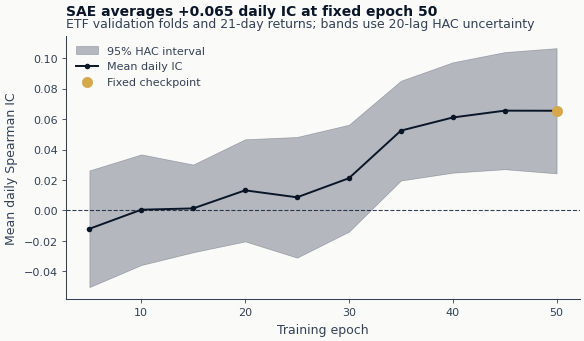

In [8]:
epochs = checkpoint_metrics["epoch"].to_numpy()
ic_values = checkpoint_metrics["mean_ic"].to_numpy()
ci_lower = checkpoint_metrics["ci_hac_lower"].to_numpy()
ci_upper = checkpoint_metrics["ci_hac_upper"].to_numpy()

fig, ax = plt.subplots()
ax.fill_between(
    epochs,
    ci_lower,
    ci_upper,
    color=COLORS["blue_light"],
    alpha=0.3,
    label="95% HAC interval",
)
ax.plot(epochs, ic_values, color=COLORS["blue"], marker="o", label="Mean daily IC")
ax.scatter(
    [REPORTING_CHECKPOINT],
    [daily_stats["mean_ic"]],
    color=COLORS["amber"],
    s=55,
    zorder=3,
    label="Fixed checkpoint",
)
zero_line(ax)
ax.set_xlabel("Training epoch")
ax.set_ylabel("Mean daily Spearman IC")
ax.legend(frameon=False, loc="upper left")
add_message_title(
    ax,
    f"SAE averages {daily_stats['mean_ic']:+.3f} daily IC at fixed epoch 50",
    subtitle="ETF validation folds and 21-day returns; bands use 20-lag HAC uncertainty",
)
display(
    fig,
    metadata={
        "image/png": {
            "alt": "Mean daily SAE rank IC by training checkpoint, with HAC intervals and the "
            "fixed epoch-50 endpoint."
        }
    },
)
plt.close(fig)

In [9]:
inference = (
    "statistically inconclusive"
    if daily_stats["ci_hac_lower"] <= 0 <= daily_stats["ci_hac_upper"]
    else "statistically distinguishable from zero"
)
display(
    Markdown(
        f"""
## Takeaways

- The fixed epoch-{REPORTING_CHECKPOINT} checkpoint averages
  **{daily_stats["mean_ic"]:+.4f} daily IC** across {daily_stats["n_days"]:,} validation dates,
  with a 95% HAC interval of
  **[{daily_stats["ci_hac_lower"]:+.4f}, {daily_stats["ci_hac_upper"]:+.4f}]**
  (*t* = {daily_stats["t_hac"]:.2f}, *p* = {daily_stats["p_hac"]:.4f}). The estimate is
  {inference}.
- Checkpoint {int(validation_max["epoch"])} has the largest observed validation IC, but it remains
  a diagnostic and cannot replace the fixed reporting endpoint.
- The shared runner used {execution_mode}. A cache miss follows the same specification and prefers
  CUDA when available; seeded GPU training can still show small floating-point differences.
- The backward-selected ETF universe and finalized-FRED yield-curve features make this a
  retrospective development result, not a live or unbiased holdout estimate.

**Next:** `12_causal_dml` tests whether the momentum signal has a stable causal interpretation;
`13_model_analysis` compares SAE with the other accepted model families. See Chapter 14,
Section 14.7.
"""
    )
)


## Takeaways

- The fixed epoch-50 checkpoint averages
  **+0.0654 daily IC** across 2,016 validation dates,
  with a 95% HAC interval of
  **[+0.0243, +0.1066]**
  (*t* = 3.12, *p* = 0.0018). The estimate is
  statistically distinguishable from zero.
- Checkpoint 45 has the largest observed validation IC, but it remains
  a diagnostic and cannot replace the fixed reporting endpoint.
- The shared runner used registry cache. A cache miss follows the same specification and prefers
  CUDA when available; seeded GPU training can still show small floating-point differences.
- The backward-selected ETF universe and finalized-FRED yield-curve features make this a
  retrospective development result, not a live or unbiased holdout estimate.

**Next:** `12_causal_dml` tests whether the momentum signal has a stable causal interpretation;
`13_model_analysis` compares SAE with the other accepted model families. See Chapter 14,
Section 14.7.
